# 01 · Data exploration, cleaning & derivation
**Team DSA · NEXUS DELTA · Build for Bharat 2.0 Round 2**  
Run top-to-bottom (Colab: Runtime → Run all). Notebooks 01→06 share files in `out/`.

In [1]:
import os, json, re, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)
# ---- Colab: upload the 4 organiser files to /content (left sidebar) or mount Drive and change DATA_DIR ----
DATA_DIR = "."
os.makedirs("figs", exist_ok=True); os.makedirs("out", exist_ok=True)
RES = "out/results.json"
def save_res(key, val):
    r = json.load(open(RES)) if os.path.exists(RES) else {}
    r[key] = val
    json.dump(r, open(RES, "w"), indent=1, default=float)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold"})
C = {"navy": "#12355b", "teal": "#1b998b", "amber": "#e09f3e", "red": "#c8553d", "grey": "#8d99ae"}

## 1. Load & profile the four organiser datasets

In [2]:
A_RAW = pd.read_csv(f"{DATA_DIR}/Analytics_Jobs.csv")
DS    = pd.read_csv(f"{DATA_DIR}/DataScience_Jobs.csv")
JDS   = pd.read_excel(f"{DATA_DIR}/JDS_Skill_Traits.xlsx")
SDS   = pd.read_excel(f"{DATA_DIR}/SDS_Personality_Traits.xlsx")
prof = {}
for n, d in [("Analytics_Jobs", A_RAW), ("DataScience_Jobs", DS), ("JDS", JDS), ("SDS", SDS)]:
    prof[n] = dict(rows=len(d), cols=d.shape[1], missing_cells=int(d.isna().sum().sum()))
    print(f"{n:17s} rows={len(d):6d} cols={d.shape[1]} missing_cells={int(d.isna().sum().sum())}")
print("\nAnalytics_Jobs missing % by column:"); print((A_RAW.isna().mean()*100).round(1).to_string())
key_cols = [c for c in A_RAW.columns if c != "s_no"]
n_dup = int(A_RAW.duplicated(subset=key_cols).sum())
trunc = A_RAW.key_skills.fillna("").str.rstrip().str.endswith("...")
print(f"\nexact duplicate postings (ignoring s_no): {n_dup}")
print(f"truncated key_skills ('...'): {int(trunc.sum())} ({trunc.mean()*100:.1f}%)")
print("job_type raw spellings:", A_RAW.job_type.value_counts(dropna=False).to_dict())

Analytics_Jobs    rows= 15841 cols=8 missing_cells=15520
DataScience_Jobs  rows=  1602 cols=8 missing_cells=0
JDS               rows=   139 cols=7 missing_cells=0
SDS               rows=   161 cols=7 missing_cells=0

Analytics_Jobs missing % by column:
s_no                0.0
experience          0.0
job_description    22.1
job_desig           0.0
job_type           75.8
key_skills          0.0
location            0.0
salary              0.0

exact duplicate postings (ignoring s_no): 1001
truncated key_skills ('...'): 13806 (87.2%)
job_type raw spellings: {nan: 12011, 'Analytics': 2971, 'analytics': 746, 'ANALYTICS': 64, 'analytic': 30, 'Analytic': 19}


## 2. Identifier audit: why a row-level join is invalid

In [3]:
ids = {"DS.reference_no": set(DS.reference_no), "A.s_no": set(A_RAW.s_no), "JDS.id": set(JDS.id), "SDS.id": set(SDS.id)}
ov = {}
import itertools
for (k1, s1), (k2, s2) in itertools.combinations(ids.items(), 2):
    ov[f"{k1} ∩ {k2}"] = len(s1 & s2); print(f"{k1:16s} ∩ {k2:16s} = {len(s1 & s2)}")
print("DS (company,title) unique?", not DS.duplicated(["company_name","job_title"]).any(),
      "| reference_no reused:", int(DS.reference_no.duplicated(keep=False).sum()), "rows")
save_res("id_overlap", ov)

DS.reference_no  ∩ A.s_no           = 1460
DS.reference_no  ∩ JDS.id           = 21
DS.reference_no  ∩ SDS.id           = 33
A.s_no           ∩ JDS.id           = 137
A.s_no           ∩ SDS.id           = 152
JDS.id           ∩ SDS.id           = 0
DS (company,title) unique? True | reference_no reused: 276 rows


## 3. Cleaning rules for Analytics_Jobs (each rule logged for row reconciliation)

In [4]:
log = [("raw rows", len(A_RAW))]
a = A_RAW.drop_duplicates(subset=key_cols, keep="first").copy(); log.append(("after exact-duplicate drop", len(a)))
a["trunc_skills"]  = a.key_skills.fillna("").str.rstrip().str.endswith("...")
a["jobtype_missing"] = a.job_type.isna()
a["desc_missing"]  = a.job_description.isna()
a["key_skills"]    = a.key_skills.fillna("")
a["job_description"] = a.job_description.fillna("")
# experience "5-10 yrs" -> exp_min / exp_max / exp_span
m = a.experience.str.extract(r"(\d+)\s*-\s*(\d+)").astype(float)
a["exp_min"], a["exp_max"] = m[0], m[1]; a["exp_span"] = a.exp_max - a.exp_min
log.append(("experience parse failures", int(a.exp_min.isna().sum())))
a = a.dropna(subset=["exp_min"]).copy(); log.append(("after dropping unparseable experience", len(a)))
# salary band -> ordinal 0..5
BANDS = ["0to3","3to6","6to10","10to15","15to25","25to50"]
a["salary_ord"] = a.salary.map({b:i for i,b in enumerate(BANDS)}).astype(int)
# job_type spelling normalisation (missing stays missing, flagged above)
a["job_type_norm"] = a.job_type.str.lower().str.strip().replace({"analytic":"analytics"})
# location tier
T1 = r"bengaluru|bangalore|mumbai|delhi|ncr|gurgaon|gurugram|noida|hyderabad|chennai|pune|kolkata|navi mumbai"
FOREIGN = r"dubai|singapore|london|usa|united states|new york|san francisco|\buk\b|canada|australia|kuala|doha|riyadh|abu dhabi|germany|netherlands|paris|toronto|tokyo|hong kong|saudi|qatar|bahrain|kuwait|oman|ireland|sydney|melbourne|manila|jakarta|nairobi|lagos"
loc = a.location.str.lower()
a["loc_tier"] = np.where(loc.str.contains(T1), "Tier1", np.where(loc.str.contains(FOREIGN), "International", "Tier2_3"))
# seniority from designation (first match wins)
SEN = [(r"\bhead\b|\bvp\b|vice president|director|chief|\bcto\b|\bcxo\b","head"),
       (r"principal|architect|\blead\b|leader|manager|\bmgr\b","lead_mgr"),
       (r"senior|\bsr\b|\bsr\.","senior"),
       (r"fresher|trainee|\bintern\b|internship|junior|\bjr\b|graduate|associate","junior")]
def seniority(t):
    t = str(t).lower()
    for pat, lab in SEN:
        if re.search(pat, t): return lab
    return "mid"
a["seniority"] = a.job_desig.map(seniority)
RF = [(r"data scien|machine learning|\bml\b|\bai\b|deep learning|nlp","DS_ML"),
      (r"data engineer|big data|hadoop|etl|data warehouse|spark","DE"),
      (r"business analyst|\bba\b","BA"),
      (r"data analyst|analytics|\bbi\b|business intelligence|insight|reporting|\bmis\b|analyst","DA_BI")]
def rolefam(t):
    t = str(t).lower()
    for pat, lab in RF:
        if re.search(pat, t): return lab
    return "other"
a["role_family"] = a.job_desig.map(rolefam)
SPAM = r"urgent|hiring|walk.?in|vacanc|openings?|apply|work from home|earn |\$|₹|!!|requirement"
a["spam_title"] = a.job_desig.str.contains(SPAM, case=False, regex=True) | (a.job_desig.str.len() > 80)
for k, v in log: print(f"{k:42s} {v}")
print("\nloc_tier:", a.loc_tier.value_counts().to_dict())
print("seniority:", a.seniority.value_counts().to_dict())
print("role_family:", a.role_family.value_counts().to_dict())
print("spam-like titles flagged:", int(a.spam_title.sum()))

raw rows                                   15841
after exact-duplicate drop                 14840
experience parse failures                  0
after dropping unparseable experience      14840

loc_tier: {'Tier1': 13329, 'Tier2_3': 1360, 'International': 151}
seniority: {'mid': 7796, 'lead_mgr': 4091, 'senior': 1553, 'head': 777, 'junior': 623}
role_family: {'other': 9417, 'DA_BI': 3580, 'BA': 734, 'DS_ML': 640, 'DE': 469}
spam-like titles flagged: 1722


## 4. Capability taxonomy `cap-tax-v2.0` (versioned regex instrument) — primary (designation+skills) and wide (+description)

In [5]:
TAX = {
 "big_data":   r"hadoop|spark|hive|big data|bigdata|pyspark|kafka|hbase|mapreduce|nosql|cassandra|mongodb|data lake|\bhdfs\b",
 "maths_stats":r"statistic|regression|forecast|probabilit|hypothesis|\bsas\b|spss|econometric|optimi[sz]ation|operations research|mathemat|time series|\banova\b|predictive model|a/b test",
 "coding":     r"python|\bjava\b|\bscala\b|c\+\+|\bsql\b|programming|javascript|\bperl\b|\bruby\b|\bgolang\b|\br\b programming|\br\b,|, r,|\bpandas\b",
 "ai_ml":      r"machine learning|\bml\b|deep learning|\bnlp\b|tensorflow|pytorch|neural|artificial intelligence|\bai\b|computer vision|scikit|keras|data scien|\bllm\b|natural language",
 "viz":        r"tableau|power ?bi|powerbi|qlik|visuali[sz]|dashboard|looker|data studio|\bd3\b|spotfire|storytell|\bcognos\b",
 "mis":        r"\bmis\b|reporting|\breports?\b|excel|\bvba\b|business objects|crystal report"}
DATA_ROLE_P = r"data|analy|scien|machine learning|\bml\b|\bai\b|business intelligence|\bbi\b|statistic|insight|quant|research|mis\b"
DATA_ROLE_W = DATA_ROLE_P + r"|tableau|power ?bi|hadoop|spark|etl|sas|data mining|predictive|forecast"
json.dump({"TAX": TAX, "DATA_ROLE_P": DATA_ROLE_P, "DATA_ROLE_W": DATA_ROLE_W, "SEN": SEN, "RF": RF, "T1": T1, "FOREIGN": FOREIGN}, open("out/taxonomy.json","w"), indent=1)   # versioned taxonomy artefact
a["text_p"] = (a.job_desig + " " + a.key_skills).str.lower()
a["text_w"] = (a.text_p + " " + a.job_description.str.lower())
for k, pat in TAX.items():
    a[f"{k}_p"] = a.text_p.str.contains(pat, regex=True).astype(int)
    a[f"{k}_w"] = a.text_w.str.contains(pat, regex=True).astype(int)
for s in ["p","w"]:
    a[f"story_{s}"] = ((a[f"viz_{s}"]==1) | (a[f"mis_{s}"]==1)).astype(int)
    a[f"mis_only_{s}"] = ((a[f"mis_{s}"]==1) & (a[f"viz_{s}"]==0)).astype(int)
a["is_ds_p"] = a.job_desig.str.lower().str.contains(DATA_ROLE_P, regex=True)
a["is_ds_w"] = a.text_w.str.contains(DATA_ROLE_W, regex=True)
print("primary DS&A population:", int(a.is_ds_p.sum()), "| wide population:", int(a.is_ds_w.sum()), "of", len(a))
prev = pd.DataFrame({k:[a.loc[a.is_ds_p,f"{k}_p"].mean(), a.loc[a.is_ds_w,f"{k}_w"].mean()] for k in ["big_data","maths_stats","coding","ai_ml","viz","mis","story"]}, index=["primary","wide"]).T
print((prev*100).round(1).to_string())
save_res("cleaning", dict(raw=len(A_RAW), dup=n_dup, trunc=int(trunc.sum()), trunc_pct=float(trunc.mean()*100),
         clean=len(a), jobtype_missing=int(a.jobtype_missing.sum()), jobtype_missing_pct=float(a.jobtype_missing.mean()*100),
         desc_missing_raw=int(A_RAW.job_description.isna().sum()), ds_primary=int(a.is_ds_p.sum()), ds_wide=int(a.is_ds_w.sum()),
         spam=int(a.spam_title.sum()), log=log, prevalence=(prev*100).round(1).to_dict()))
a.drop(columns=["text_p","text_w"]).to_csv("out/analytics_clean.csv", index=False)
a[["job_desig","key_skills","job_description","exp_min","exp_max","loc_tier","seniority","role_family","salary_ord","is_ds_p","is_ds_w"]+[c for c in a.columns if c.endswith(("_p","_w"))]]  # sanity

primary DS&A population: 6097 | wide population: 10338 of 14840
             primary  wide
big_data         9.5   7.8
maths_stats     17.2  16.8
coding          29.4  26.3
ai_ml           14.4  10.3
viz              5.4   5.0
mis             13.0  15.0
story           16.5  18.1


,job_desig,key_skills,job_description,exp_min,exp_max,loc_tier,seniority,role_family,salary_ord,is_ds_p,...,viz_p,viz_w,mis_p,mis_w,story_p,mis_only_p,story_w,mis_only_w,is_ds_p,is_ds_w
0,Oracle EBS Technical Consultant,"Oracle SQL, PLSQL, PL, Oracle Forms, Oracle Re...",Must be knowledgeable and experienced in relat...,6.0,10.0,Tier1,mid,other,2,False,...,0,0,1,1,1,1,1,1,False,True
1,Staff Software Engineer - Object Oriented Anal...,"Javascript, HTML, JQuery, Web Development, Pla...",- Experience in building scalable and highly a...,8.0,12.0,Tier1,mid,other,3,True,...,0,0,0,0,0,0,0,0,True,True
2,Servicenow Developer,"SNOW, Servicenow, Servicenow Developer",,3.0,8.0,Tier1,mid,other,0,False,...,0,0,0,0,0,0,0,0,False,False
3,"Software Development Engineering, Analyst","QTP, Flex, LAN, Application support, Performan...",Our software engineers at Fiserv bring an...,3.0,6.0,Tier1,mid,DA_BI,2,True,...,0,0,0,0,0,0,0,0,True,True
4,NVH Engineer - Nastran/ Ls-dyna,"HyperMesh, LS - DYNA, NASTRAN, Abaqus, Fatigue...",- More than 5 years experience in Hypermesh fo...,5.0,10.0,Tier1,mid,other,3,False,...,0,0,0,0,0,0,0,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15836,Business Analyst - KPO - IIT / NIT/ Nsit/ DSE,"Statistical Modeling, Data Analysis, Business ...",- Analyze & interpret data and communicate res...,1.0,2.0,Tier1,mid,BA,3,True,...,0,0,0,0,0,0,0,0,True,True
15837,Front End Developer/ui Developer - Javascript/...,"UI Development, Javascript, HTML, Html5, Photo...",- Experience in object oriented programming / ...,3.0,8.0,Tier1,mid,other,4,False,...,0,0,0,0,0,0,0,0,False,False
15838,Business Analyst,"Test Planning, Test Strategy, Requirement Gath...",Should be ready to travel on short or medium t...,6.0,10.0,Tier1,mid,BA,3,True,...,0,0,0,0,0,0,0,0,True,True
15839,Associate Manager - Deal Advisory / M&A - Busi...,"mba finance, company profiling, pitch books, p...",,3.0,6.0,Tier1,lead_mgr,other,3,True,...,0,0,0,0,0,0,0,0,True,True


## 5. Exploratory figures

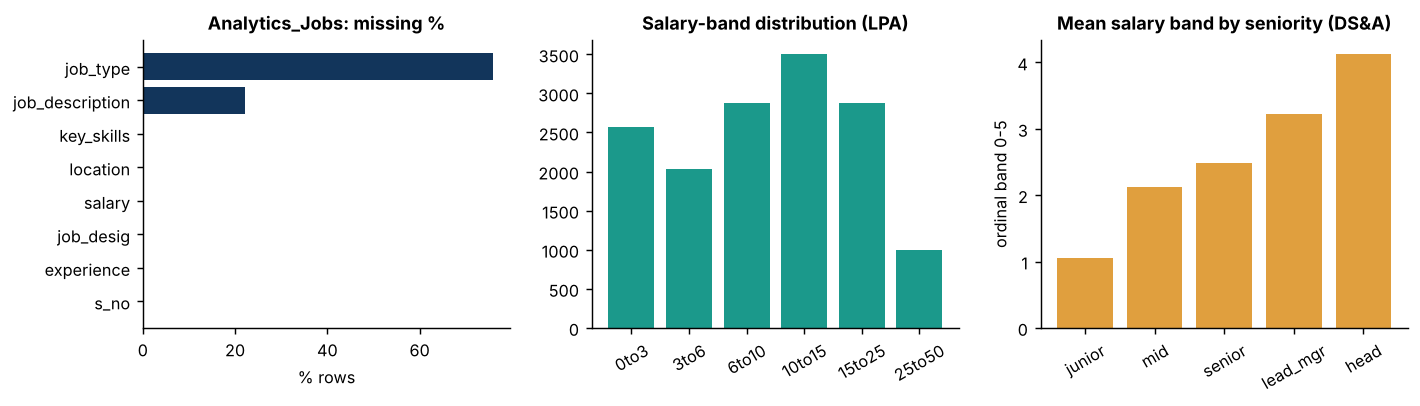

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
miss = (A_RAW.isna().mean()*100).sort_values()
ax[0].barh(miss.index, miss.values, color=C["navy"]); ax[0].set_title("Analytics_Jobs: missing %"); ax[0].set_xlabel("% rows")
sal = a.salary_ord.value_counts().sort_index()
ax[1].bar([BANDS[i] for i in sal.index], sal.values, color=C["teal"]); ax[1].set_title("Salary-band distribution (LPA)"); ax[1].tick_params(axis="x", rotation=30)
sen = a[a.is_ds_p].groupby("seniority").salary_ord.mean().reindex(["junior","mid","senior","lead_mgr","head"])
ax[2].bar(sen.index, sen.values, color=C["amber"]); ax[2].set_title("Mean salary band by seniority (DS&A)"); ax[2].tick_params(axis="x", rotation=30); ax[2].set_ylabel("ordinal band 0-5")
plt.tight_layout(); plt.savefig("figs/fig01_explore.png", bbox_inches="tight"); plt.show()